In [3]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="12345",
    database="spotify_database"
)

query =""" 
SELECT 
    t.track_name, COUNT(pt.track_id) AS Number_of_tracks
FROM
    tracks t
        LEFT JOIN
    playlist_tracks pt ON t.track_id = pt.track_id
GROUP BY t.track_name
ORDER BY Number_of_tracks DESC
LIMIT 10;"""

df = pd.read_sql(query, connection)

df.head(10)

C:\Users\rampa\AppData\Local\Temp\ipykernel_1348\3108829254.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,track_name,Number_of_tracks
0,Fire Rise,14
1,Rise Again,11
2,Freedom Heart,11
3,Lost Higher,11
4,Love Beautiful,10


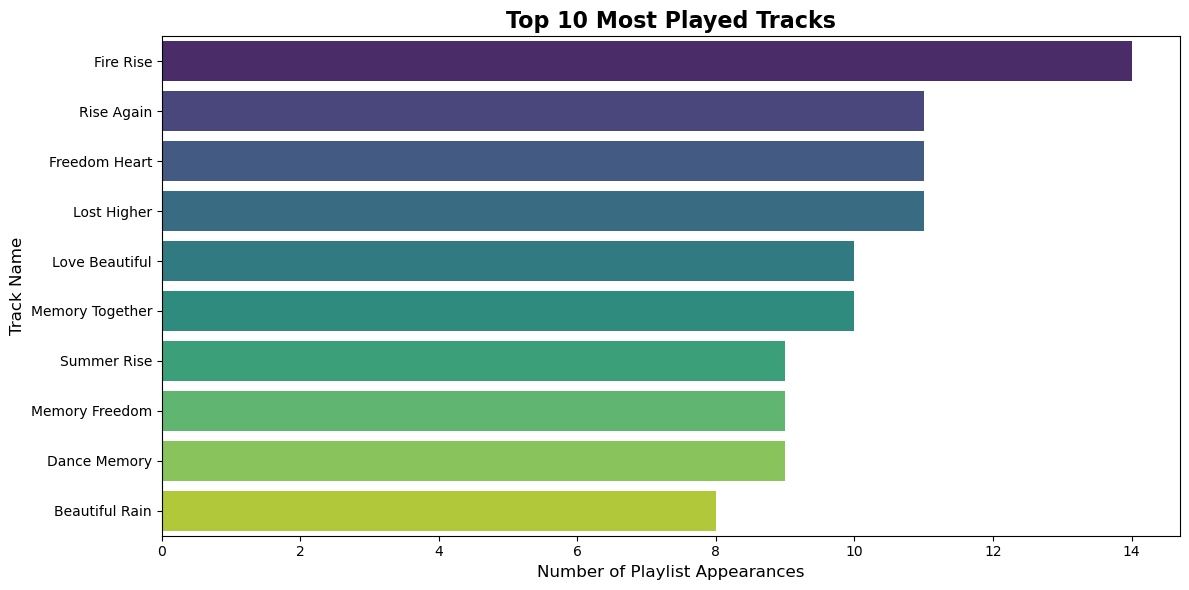

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Number_of_tracks",
    y="track_name",
    palette="viridis",
    hue="track_name",
    legend=False
)

plt.title("Top 10 Most Played Tracks", fontsize=16, fontweight="bold")
plt.xlabel("Number of Playlist Appearances", fontsize=12)
plt.ylabel("Track Name", fontsize=12)

plt.tight_layout()
plt.show()